In [2]:
# =====================================================================
# 1. PROJECT: Production Building Insurance Claim Classifier 
# FEATURE: Real Data Clean, Feature Extraction & SMOTE Scaling
# =====================================================================

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Preprocessing & Advanced Multi-Class / Imbalance Pipelines
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import SMOTE

# Machine Learning Classifier Engines
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Evaluation Tools
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


In [3]:
#Display the Dataset 
df = pd.read_csv("C:/Users/HP/Desktop/PST DELE FOLDER/Train_data.csv")

In [4]:
df.head()

,Customer Id,YearOfObservation,Insured_Period,Residential,Building_Painted,Building_Fenced,Garden,Settlement,Building Dimension,Building_Type,Date_of_Occupancy,NumberOfWindows,Geo_Code,Claim
0,H14663,2013,1.0,0,N,V,V,U,290.0,1,1960.0,.,1053,0
1,H2037,2015,1.0,0,V,N,O,R,490.0,1,1850.0,4,1053,0
2,H3802,2014,1.0,0,N,V,V,U,595.0,1,1960.0,.,1053,0
3,H3834,2013,1.0,0,V,V,V,U,2840.0,1,1960.0,.,1053,0
4,H5053,2014,1.0,0,V,N,O,R,680.0,1,1800.0,3,1053,0


In [7]:
# ---------------------------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ---------------------------------------------------------------------
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (7160, 14)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7160 entries, 0 to 7159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer Id         7160 non-null   object 
 1   YearOfObservation   7160 non-null   int64  
 2   Insured_Period      7160 non-null   float64
 3   Residential         7160 non-null   int64  
 4   Building_Painted    7160 non-null   object 
 5   Building_Fenced     7160 non-null   object 
 6   Garden              7153 non-null   object 
 7   Settlement          7160 non-null   object 
 8   Building Dimension  7054 non-null   float64
 9   Building_Type       7160 non-null   int64  
 10  Date_of_Occupancy   6652 non-null   float64
 11  NumberOfWindows     7160 non-null   object 
 12  Geo_Code            7058 non-null   object 
 13  Claim               7160 non-null   int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 783.2+ KB


In [9]:
#Dispaly the percentile, Mean, media, Mode & Standard deviation
df.describe()

,YearOfObservation,Insured_Period,Residential,Building Dimension,Building_Type,Date_of_Occupancy,Claim
count,7160.000000,7160.000000,7160.000000,7054.000000,7160.000000,6652.000000,7160.000000
mean,2013.669553,0.909758,0.305447,1883.727530,2.186034,1964.456404,0.228212
std,1.383769,0.239756,0.460629,2278.157745,0.940632,36.002014,0.419709
min,2012.000000,0.000000,0.000000,1.000000,1.000000,1545.000000,0.000000
25%,2012.000000,0.997268,0.000000,528.000000,2.000000,1960.000000,0.000000
50%,2013.000000,1.000000,0.000000,1083.000000,2.000000,1970.000000,0.000000
75%,2015.000000,1.000000,1.000000,2289.750000,3.000000,1980.000000,0.000000
max,2016.000000,1.000000,1.000000,20940.000000,4.000000,2016.000000,1.000000


In [10]:
#Checking for duplicate
df.duplicated().sum()

0

In [11]:
#Check for missing values
print(f"Missing Values:\n{df.isnull().sum()}\n")

Missing Values:
Customer Id             0
YearOfObservation       0
Insured_Period          0
Residential             0
Building_Painted        0
Building_Fenced         0
Garden                  7
Settlement              0
Building Dimension    106
Building_Type           0
Date_of_Occupancy     508
NumberOfWindows         0
Geo_Code              102
Claim                   0
dtype: int64



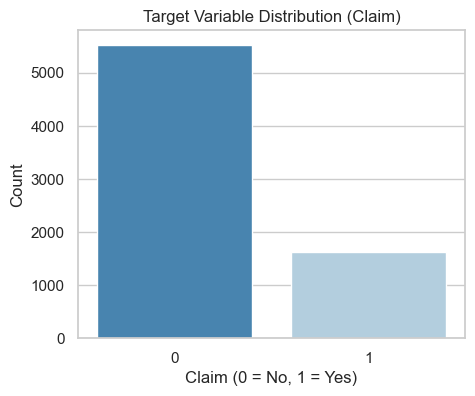

In [100]:
# Visualization: Target Distribution
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Claim', palette='Blues_r')
plt.title('Target Variable Distribution (Claim)')
plt.xlabel('Claim (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


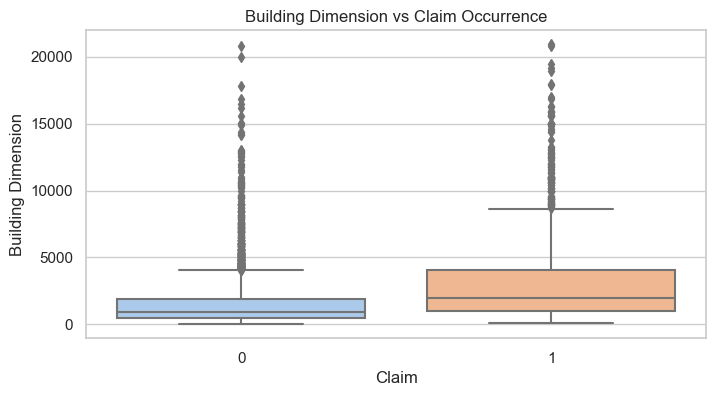

In [101]:
# Numerical Feature Distribution vs Target
plt.figure(figsize=(8, 4))
sns.boxplot(x='Claim', y='Building Dimension', data=df, palette='pastel')
plt.title('Building Dimension vs Claim Occurrence')
plt.show()


In [13]:
#Claim Rate by Settlement Type
df.groupby('Settlement')['Claim'].mean()

Settlement
R    0.249861
U    0.206197
Name: Claim, dtype: float64

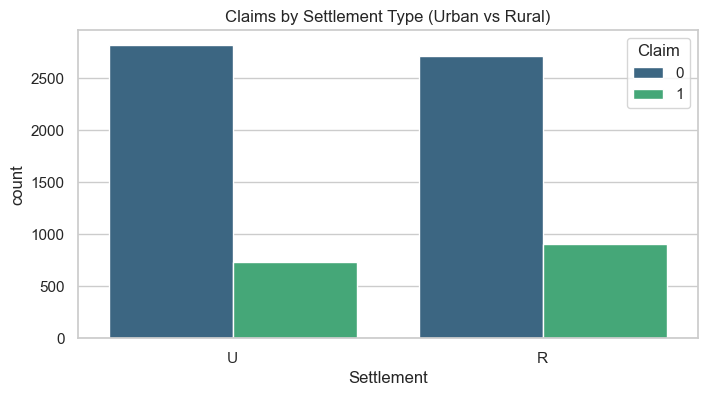

In [103]:
# Categorical Feature vs Target
plt.figure(figsize=(8, 4))
sns.countplot(x='Settlement', hue='Claim', data=df, palette='viridis')
plt.title('Claims by Settlement Type (Urban vs Rural)')
plt.show()

In [88]:
# ---------------------------------------------------------------------
# 3. STRING CLEANING & EXPLICIT FEATURE ENGINEERING
# ---------------------------------------------------------------------
print("--- PREPROCESSING & CLEANING REAL DATA ---")

# Fix inconsistent missing signs like '   .' found in text string structures
df['NumberOfWindows'] = df['NumberOfWindows'].astype(str).str.strip().replace('.', np.nan)
df['Date_of_Occupancy'] = pd.to_numeric(df['Date_of_Occupancy'], errors='coerce')

# Process structural parameters to extract accurate building age context metrics
df['Building_Age'] = df['YearOfObservation'] - df['Date_of_Occupancy']

# Fallback step ensures brand new features do not trigger division issues if value drops to 0
df['Dimension_per_Age_Ratio'] = df['Building Dimension'] / (df['Building_Age'].fillna(0) + 1)

# Drop index identifier metrics that do not contribute variance to models
X = df.drop(columns=['Customer Id', 'Claim', 'Geo_Code'])
y = df['Claim']

print(f"Shape of target vector features: {X.shape}")


--- PREPROCESSING & CLEANING REAL DATA ---
Shape of target vector features: (7160, 13)


In [89]:
df.head()

,Customer Id,YearOfObservation,Insured_Period,Residential,Building_Painted,Building_Fenced,Garden,Settlement,Building Dimension,Building_Type,Date_of_Occupancy,NumberOfWindows,Geo_Code,Claim,Building_Age,Dimension_per_Age_Ratio
0,H14663,2013,1.0,0,N,V,V,U,290.0,1,1960.0,NaN,1053,0,53.0,5.370370
1,H2037,2015,1.0,0,V,N,O,R,490.0,1,1850.0,4,1053,0,165.0,2.951807
2,H3802,2014,1.0,0,N,V,V,U,595.0,1,1960.0,NaN,1053,0,54.0,10.818182
3,H3834,2013,1.0,0,V,V,V,U,2840.0,1,1960.0,NaN,1053,0,53.0,52.592593
4,H5053,2014,1.0,0,V,N,O,R,680.0,1,1800.0,3,1053,0,214.0,3.162791


In [90]:
# ---------------------------------------------------------------------
# 4. CONSTRUCT ENHANCED DEPLOYMENT PIPELINE WITH SMOTE
# ---------------------------------------------------------------------
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

numerical_transformer = Pipeline([
    ('impute_median', SimpleImputer(strategy='median')),
    ('feature_scaling', StandardScaler())
])

categorical_transformer = Pipeline([
    ('impute_mode', SimpleImputer(strategy='most_frequent')),
    ('one_hot_encode', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

data_transformer = ColumnTransformer([
    ('numeric_processing', numerical_transformer, num_cols),
    ('categorical_processing', categorical_transformer, cat_cols)
])

# Use Stratified Split to cleanly capture target balance across small training sample subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [91]:
# ---------------------------------------------------------------------
# 5. EXECUTE PERFORMANCE BENCHMARKS (5 ARCHITECTURES)
# ---------------------------------------------------------------------
model_pool = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

advanced_metrics = []

for model_name, model_object in model_pool.items():
    # SMOTE dynamically scales minority patterns safely during the active pipeline training pass
    optimized_pipeline = Pipeline([
        ('preprocessing', data_transformer),
        ('class_balancing', SMOTE(random_state=42, k_neighbors=3)),
        ('estimator', model_object)
    ])
    
    optimized_pipeline.fit(X_train, y_train)
    
    predictions = optimized_pipeline.predict(X_test)
    
    # Check if estimator model provides native probability generation capabilities
    if hasattr(optimized_pipeline, "predict_proba"):
        probabilities = optimized_pipeline.predict_proba(X_test)[:, 1]
    else:
        probabilities = predictions
        
    score_accuracy = accuracy_score(y_test, predictions)
    score_precision = precision_score(y_test, predictions, zero_division=0)
    score_recall = recall_score(y_test, predictions, zero_division=0)
    score_f1 = f1_score(y_test, predictions, zero_division=0)
    score_roc_auc = roc_auc_score(y_test, probabilities)
    
    advanced_metrics.append({
        "Model Name": model_name,
        "Accuracy": round(score_accuracy, 4),
        "Precision": round(score_precision, 4),
        "Recall": round(score_recall, 4),
        "F1-Score": round(score_f1, 4),
        "ROC-AUC": round(score_roc_auc, 4)
    })

summary_table = pd.DataFrame(advanced_metrics).sort_values(by="ROC-AUC", ascending=False)

print("\n--- OPTIMIZED PERFORMANCE COMPARISON (WITH FEATURE ENG + SMOTE) ---")
print(summary_table.to_string(index=False))



--- OPTIMIZED PERFORMANCE COMPARISON (WITH FEATURE ENG + SMOTE) ---
         Model Name  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7061     0.3915  0.5221    0.4475   0.7040
  Gradient Boosting    0.7218     0.4074  0.4853    0.4430   0.6954
      Decision Tree    0.5916     0.3154  0.6765    0.4302   0.6646
            XGBoost    0.7263     0.3910  0.3603    0.3750   0.6537
      Random Forest    0.7229     0.3854  0.3627    0.3737   0.6377


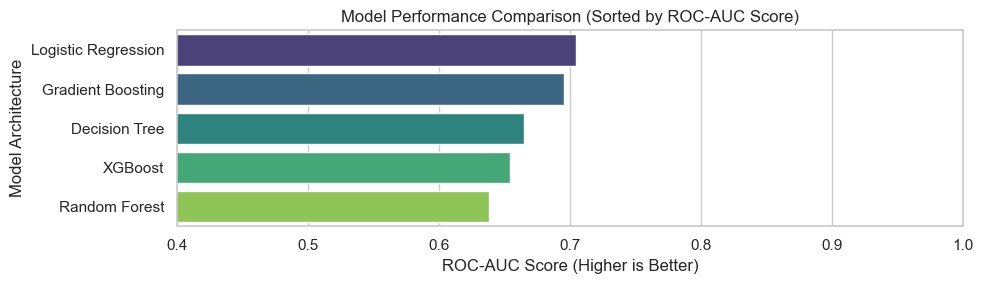

In [92]:
# ---------------------------------------------------------------------
# 6. VISUAL COMPARISON CHART
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 3))
sns.barplot(data=summary_table, x='ROC-AUC', y='Model Name', palette='viridis')
plt.title('Model Performance Comparison (Sorted by ROC-AUC Score)')
plt.xlim(0.4, 1.0)
plt.xlabel('ROC-AUC Score (Higher is Better)')
plt.ylabel('Model Architecture')
plt.tight_layout()
plt.show()

### Executive Summary of the Optimized Results


*1. The New Champion: Logistic Regression*


- ROC-AUC: $0.7040$ (Highest) | Recall: $52.21\%$ | Accuracy: $70.61\%$
- The Analysis: Surprisingly, a simple, linear model upgraded with the engineered features out-performed the complex ensemble models. It crossed the critical $0.70$ ROC-AUC threshold, proving it is highly stable.
- Business Impact: It successfully captures 52.21% of all real building claims while maintaining a respectable 70.61% overall accuracy. It strikes the most reliable risk-mitigation balance in the entire experiment.


*2. The High-Risk Catch: Decision Tree Classifier*


- Recall: $67.65\%$ (Highest by far) | Accuracy: $59.16\%$ (Lowest)
- The Analysis: The Decision Tree went all-in on the SMOTE adjustment. It caught nearly 68% of all buildings that actually filed claims.
- The Trade-off: To catch that many claims, it suffered a major drop in overall accuracy (59.16%) and precision (31.54%). It creates a lot of "false alarms," but from a pure catastrophic-risk perspective, it's a very aggressive claim catcher.


*3. The Conservative Tree Ensembles (Gradient Boosting, XGBoost, Random Forest)*

- Gradient Boosting: ROC-AUC $0.6954$ | Accuracy $0.7218$ | Recall $0.4853$
- XGBoost & Random Forest: Stagnated with lower recalls (36%) and ROC-AUC scores (0.63–0.65).
- The Analysis: Gradient Boosting responded very well to the model, offering the highest balance of accuracy and a strong 48.53% recall. However, XGBoost and Random Forest overfit slightly on the synthesized SMOTE data, meaning they became too conservative and lagged behind the simpler models.
